
# Business Objective – Home Credit Application Dataset

## Business Objective

Home Credit provides loans to customers who may have limited or no traditional credit history. The main business objective is to analyze loan applicant information and identify meaningful groups of applicants with similar financial, demographic, employment, and credit-related characteristics.

Using clustering techniques, the goal is to discover hidden customer segments without using a predefined target variable.

## Clustering Objectives

1. **Applicant Segmentation**
   - Group loan applicants based on similar financial and demographic characteristics.
   - Identify distinct types of credit applicants.

2. **Income-Based Segmentation**
   - Group applicants based on total income, loan amount, annuity amount, and other financial attributes.
   - Understand differences between low-, medium-, and high-income applicant groups.

3. **Credit Profile Segmentation**
   - Identify applicants with similar credit requirements.
   - Analyze relationships between requested credit amount, income, annuity, and goods price.

4. **Employment Profile Analysis**
   - Segment applicants based on employment-related characteristics.
   - Understand how employment duration, occupation, and income source differ across clusters.

5. **Demographic Segmentation**
   - Identify applicant groups based on age, family size, education, housing type, and other demographic characteristics.

6. **Financial Burden Analysis**
   - Identify groups with different levels of financial burden.
   - Analyze indicators such as:
     - Credit-to-Income Ratio
     - Annuity-to-Income Ratio
     - Credit-to-Goods-Price Ratio

7. **Potential Risk-Pattern Discovery**
   - Discover applicant groups whose characteristics may warrant different levels of credit review.
   - Clustering itself should not be treated as a loan-default prediction model because the test dataset does not contain the target/default label.

8. **Outlier Detection**
   - Identify applicants with unusual income, credit, annuity, employment, or demographic characteristics.
   - Detect applicants significantly different from the majority of customers.

9. **Business Decision Support**
   - Support customer segmentation and portfolio analysis.
   - Help design differentiated loan products and customer communication strategies.
   - Provide additional insights that can complement supervised credit-risk models.

## Machine Learning Objective

Apply unsupervised machine learning algorithms such as:

- K-Means Clustering
- Hierarchical / Agglomerative Clustering
- DBSCAN
- Mean Shift Clustering

Evaluate the quality of the generated clusters using:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Cluster Visualization

## Expected Outcome

The expected outcome is to divide Home Credit loan applicants into meaningful customer segments based on similarities in their financial, demographic, employment, and credit characteristics.

These clusters can then be profiled to understand different types of loan applicants and support portfolio analysis, customer segmentation, credit review, and business strategy.

In [1]:
print('test')

test


In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans,AgglomerativeClustering,MeanShift,DBSCAN
bank_dataset=pd.read_excel(r"C:\clustering\data\application_test.xlsx")

In [16]:
bank_dataset=bank_dataset[['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','CNT_FAM_MEMBERS']]

In [15]:
bank_dataset.head(10)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_REQ_CREDIT_BUREAU_YEAR.1,Unnamed: 122
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.000000e+00
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,2.000000e+00
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0.0,0.0,0.0,0.0,1.0,4.0,NaN,2.000000e+00
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,2.600000e+01
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.167404e+05
5,100042,Cash loans,F,Y,Y,0,270000.0,959688.0,34600.5,810000.0,...,0,0,0.0,0.0,0.0,0.0,1.0,2.0,NaN,2.245500e+06
6,100057,Cash loans,M,Y,Y,2,180000.0,499221.0,22117.5,373500.0,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,4.500000e+04
7,100065,Cash loans,M,N,Y,0,166500.0,180000.0,14220.0,180000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,1.784318e+05
8,100066,Cash loans,F,N,Y,0,315000.0,364896.0,28957.5,315000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,5.0,NaN,4.410000e+06
9,100067,Cash loans,F,Y,Y,1,162000.0,45000.0,5337.0,45000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,NaN,2.694150e+04


In [ ]:
bank_dataset.isna().sum()

In [17]:
def fill_null_values(df):
    for column in df.columns:
        if df[column].isna().sum() > 0:
            if df[column].dtype in ['int64', 'float64']:
                df[column] = df[column].fillna(df[column].median())
    
    return df

bank_dataset = fill_null_values(bank_dataset)

bank_dataset.isna().sum()

AMT_CREDIT           0
AMT_ANNUITY          0
AMT_GOODS_PRICE      0
DAYS_BIRTH           0
DAYS_EMPLOYED        0
DAYS_REGISTRATION    0
DAYS_ID_PUBLISH      0
CNT_FAM_MEMBERS      0
dtype: int64

In [18]:
bank_dataset

,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,CNT_FAM_MEMBERS
0,568800.0,20560.5,450000.0,-19241,-2329,-5170,-812,2
1,222768.0,17370.0,180000.0,-18064,-4469,-9118,-1623,2
2,663264.0,69777.0,630000.0,-20038,-4458,-2175,-3503,2
3,1575000.0,49018.5,1575000.0,-13976,-1866,-2000,-4208,4
4,625500.0,32067.0,625500.0,-13040,-2191,-4000,-4262,3
...,...,...,...,...,...,...,...,...
48739,412560.0,17473.5,270000.0,-19970,-5169,-9094,-3399,1
48740,622413.0,31909.5,495000.0,-11186,-1149,-3015,-3003,4
48741,315000.0,33205.5,315000.0,-15922,-3037,-2681,-1504,3
48742,450000.0,25128.0,450000.0,-13968,-2731,-1461,-1364,2


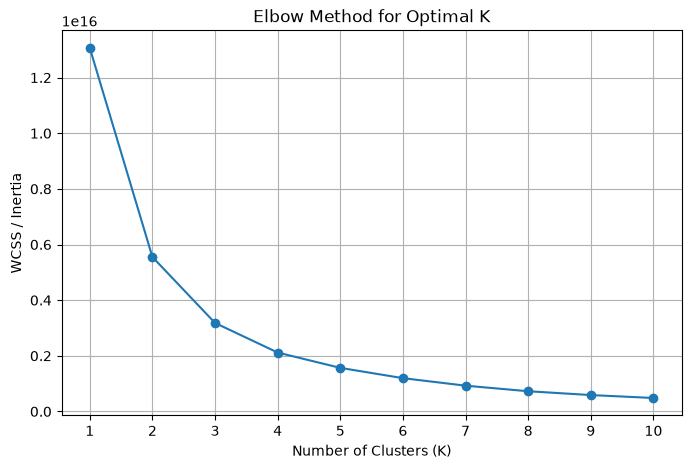

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select numerical features for clustering
X = bank_dataset[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'CNT_FAM_MEMBERS'
    ]
]

# Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid()

plt.show()

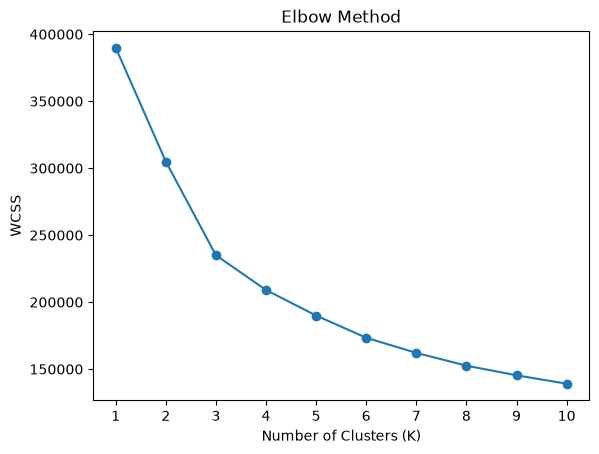

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features
X = bank_dataset[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'CNT_FAM_MEMBERS'
    ]
]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Elbow Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

In [46]:
import pandas as pd
X_scaled = pd.DataFrame(X, columns=X.columns)

In [30]:
from sklearn.cluster import KMeans

# Build K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train and predict clusters
kmeans_labels = kmeans.fit_predict(X_scaled)

print("number of unique clusters" ,np.unique(kmeans.labels_))

print("total number of rows" ,len(kmeans.labels_))
# Add cluster labels to dataset
bank_dataset['KMeans_Cluster'] = kmeans_labels

# Check number of records in each cluster
print(bank_dataset['KMeans_Cluster'].value_counts().sort_index())

number of unique clusters [0 1 2]
total number of rows 48744
KMeans_Cluster
0    29837
1     9091
2     9816
Name: count, dtype: int64


In [23]:
X_scaled[0:100]

array([[ 1.42475439e-01, -5.53579715e-01, -3.74772411e-02,
        -7.33476884e-01, -4.83656422e-01, -5.69579108e-02,
         1.42724091e+00, -1.64829867e-01],
       [-8.04537114e-01, -7.52831289e-01, -8.39361941e-01,
        -4.61392008e-01, -4.98481805e-01, -1.16826431e+00,
         9.10437016e-01, -1.64829867e-01],
       [ 4.01002378e-01,  2.52006551e+00,  4.97112559e-01,
        -9.17717875e-01, -4.98405600e-01,  7.86092412e-01,
        -2.87579416e-01, -1.64829867e-01],
       [ 2.89622084e+00,  1.22366563e+00,  3.30370901e+00,
         4.83623263e-01, -4.80448874e-01,  8.35352447e-01,
        -7.36835578e-01,  2.08131691e+00],
       [ 2.97650716e-01,  1.65018697e-01,  4.83747814e-01,
         6.99996623e-01, -4.82700392e-01,  2.72380613e-01,
        -7.71246689e-01,  9.58243522e-01],
       [ 1.21224888e+00,  3.23239623e-01,  1.03170236e+00,
        -5.86222792e-01, -5.50717034e-01, -3.23243589e-01,
         6.52990932e-01, -1.64829867e-01],
       [-4.79467951e-02, -4.563426

In [25]:
import pickle
with open("kmeans.pkl",'wb') as file:
  pickle.dump(kmeans,file)

Number of unique clusters: [0 1 2]
Total number of rows: 100

Cluster counts:
Agglomerative cluster
0    80
2    12
1     8
Name: count, dtype: int64


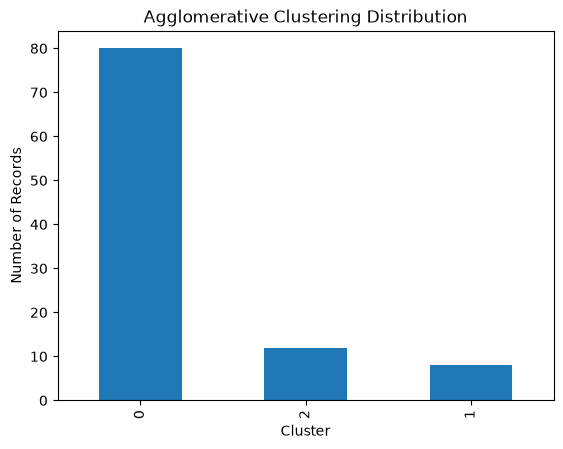

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Take first 100 rows
X_subset = X_scaled[0:100].copy()

# Build Agglomerative model
ag_model = AgglomerativeClustering(n_clusters=3)

# Predict clusters
labels = ag_model.fit_predict(X_subset)

print("Number of unique clusters:", np.unique(labels))
print("Total number of rows:", len(labels))

# Convert NumPy array to DataFrame
X_subset_df = pd.DataFrame(X_subset)

# Add cluster column
X_subset_df['Agglomerative cluster'] = labels

# Number of rows in each cluster
val = X_subset_df['Agglomerative cluster'].value_counts()

print("\nCluster counts:")
print(val)

# Visualization
X_subset_df['Agglomerative cluster'].value_counts() \
    .sort_values(ascending=False) \
    .plot(kind='bar', title='Agglomerative Clustering Distribution')

plt.xlabel('Cluster')
plt.ylabel('Number of Records')
plt.show()
    

In [47]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

db.fit_predict(X_scaled)

print("number of unique clusters", np.unique(db.labels_))

print("total number of rows", len(db.labels_))

X_scaled['DBSCAN cluster'] = db.labels_

X_scaled['DBSCAN cluster'].value_counts()

number of unique clusters [-1]
total number of rows 48744


DBSCAN cluster
-1    48744
Name: count, dtype: int64

In [48]:
from sklearn.cluster import MeanShift
X_subset = X_scaled.iloc[0:1000].copy()
ms = MeanShift(bin_seeding=True)

ms.fit_predict(X_subset)

print("number of unique clusters", np.unique(ms.labels_))

print("total number of rows", len(ms.labels_))

X_subset['MeanShift cluster'] = ms.labels_

X_subset['MeanShift cluster'].value_counts()

number of unique clusters [0 1 2 3 4]
total number of rows 1000


MeanShift cluster
0    724
1    170
3     86
2     19
4      1
Name: count, dtype: int64

In [49]:
bank_dataset.columns

Index(['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'CNT_FAM_MEMBERS', 'KMeans_Cluster'],
      dtype='str')

In [52]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans,AgglomerativeClustering,MeanShift,DBSCAN
bank_dataset_kmodes=pd.read_excel(r"C:\clustering\data\application_test.xlsx")

In [53]:
from kmodes.kmodes import KModes
import numpy as np

# Select categorical columns
X_cat = bank_dataset_kmodes[['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']]

kmod = KModes(n_clusters=5, init='huang', random_state=42)

kmod_labels = kmod.fit_predict(X_cat)

print("number of unique clusters", np.unique(kmod_labels))

print("total number of rows", len(kmod_labels))

bank_dataset_kmodes['KModes cluster'] = kmod_labels

bank_dataset_kmodes['KModes cluster'].value_counts()


number of unique clusters [0 1 2 3 4]
total number of rows 48744


C:\Users\khanr\AppData\Local\Temp\ipykernel_21716\4115599946.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bank_dataset_kmodes['KModes cluster'] = kmod_labels


KModes cluster
2    22819
0    12296
4     6180
1     4659
3     2790
Name: count, dtype: int64

In [73]:
from kmodes.kprototypes import KPrototypes
import numpy as np
import pandas as pd

# Select columns
X_kp = bank_dataset_kmodes[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'CNT_FAM_MEMBERS',
        'NAME_CONTRACT_TYPE',
        'CODE_GENDER',
        'FLAG_OWN_CAR',
        'FLAG_OWN_REALTY'
    ]
].copy()

# Fill missing numeric values
numeric_cols = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'CNT_FAM_MEMBERS'
]

for col in numeric_cols:
    X_kp[col] = pd.to_numeric(X_kp[col], errors='coerce')
    X_kp[col] = X_kp[col].fillna(X_kp[col].median())

# Fill missing categorical values
categorical_cols = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY'
]

for col in categorical_cols:
    X_kp[col] = X_kp[col].fillna('Unknown').astype(str)

# Use smaller sample first because K-Prototypes can be slow
X_kp_sample = X_kp.head(5000).copy()

kp = KPrototypes(
    n_clusters=5,
    init='Huang',
    n_init=3,
    verbose=1,
    random_state=42
)

kp_labels = kp.fit_predict(
    X_kp_sample.to_numpy(),
    categorical=[8, 9, 10, 11]
)

print("Unique clusters:", np.unique(kp_labels))
print("Total rows:", len(kp_labels))

X_kp_sample['KPrototypes_cluster'] = kp_labels

print(X_kp_sample['KPrototypes_cluster'].value_counts())

Init: initializing centroids
Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 1040, ncost: 173526701688344.72
Run: 1, iteration: 2/100, moves: 299, ncost: 168544287140531.88
Run: 1, iteration: 3/100, moves: 242, ncost: 161695607057363.16
Run: 1, iteration: 4/100, moves: 177, ncost: 156027599861021.03
Run: 1, iteration: 5/100, moves: 57, ncost: 155608936919972.66
Run: 1, iteration: 6/100, moves: 14, ncost: 155601804273137.1
Run: 1, iteration: 7/100, moves: 2, ncost: 155601569260957.4
Run: 1, iteration: 8/100, moves: 0, ncost: 155601569260957.4
Init: initializing centroids
Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 1350, ncost: 187274790685216.22
Run: 2, iteration: 2/100, moves: 338, ncost: 181788199140118.3
Run: 2, iteration: 3/100, moves: 460,

In [74]:
!pip install validclust

  Using cached validclust-0.1.1-py2.py3-none-any.whl.metadata (4.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached validclust-0.1.1-py2.py3-none-any.whl (8.1 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 2/2 [validclust]




[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
import numpy as np
import pandas as pd
import pickle

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import MeanShift

from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

from validclust import dunn

In [76]:
#X = df[['Sales', 'Profit', 'Quantity', 'Discount']].copy()

# X = X.fillna(X.median())


# ============================================================
# 1. K MEANS
# ============================================================

km = KMeans(
    n_clusters=5,
    random_state=42
)

km_labels = km.fit_predict(X_scaled)

print("\n==============================")
print("K MEANS")
print("==============================")

print("Unique Clusters:", np.unique(km_labels))

print("Total Rows:", len(km_labels))

X_scaled['KMeans cluster'] = km_labels

print(X_scaled['KMeans cluster'].value_counts())


# Silhouette Score

km_silhouette = silhouette_score(
    X_scaled,
    km_labels,
    metric='euclidean'
)

print("Silhouette Score:", km_silhouette)


# Dunn Index

km_distance = pairwise_distances(
    X_scaled,
    metric='euclidean'
)

km_dunn = dunn(
    km_distance,
    km_labels
)

print("Dunn Index:", km_dunn)


# Save Model

with open('kmeans_model_v1.pkl', 'wb') as file:
    pickle.dump(km, file)



# ============================================================
# 2. K MODES
# ============================================================

X_cat = bank_dataset_kmodes[['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']].copy()

X_cat = X_cat.fillna('Missing').astype(str)


kmod = KModes(
    n_clusters=5,
    init='Huang',
    random_state=42
)

kmod_labels = kmod.fit_predict(X_cat)


print("\n==============================")
print("K MODES")
print("==============================")

print("Unique Clusters:", np.unique(kmod_labels))

print("Total Rows:", len(kmod_labels))

bank_dataset_kmodes['KModes cluster'] = kmod_labels

print(bank_dataset_kmodes['KModes cluster'].value_counts())


# Encode categorical data for validation

X_cat_encoded = pd.get_dummies(
    X_cat
).astype(int)


# Silhouette Score

kmod_silhouette = silhouette_score(
    X_cat_encoded,
    kmod_labels,
    metric='hamming'
)

print("Silhouette Score:", kmod_silhouette)


# Dunn Index

kmod_distance = pairwise_distances(
    X_cat_encoded,
    metric='hamming'
)

kmod_dunn = dunn(
    kmod_distance,
    kmod_labels
)

print("Dunn Index:", kmod_dunn)


# Save Model

with open('kmodes_model_v1.pkl', 'wb') as file:
    pickle.dump(kmod, file)



# ============================================================
# 3. AGGLOMERATIVE CLUSTERING
# ============================================================

ag = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

ag_labels = ag.fit_predict(X_scaled[0:1000])  # Using a subset of the data for Agglomerative Clustering


print("\n==============================")
print("AGGLOMERATIVE")
print("==============================")

print("Unique Clusters:", np.unique(ag_labels))

print("Total Rows:", len(ag_labels))

X_scaled['Agglomerative cluster'] = ag_labels

print(X_scaled['Agglomerative cluster'].value_counts())


# Silhouette Score

ag_silhouette = silhouette_score(
    X_scaled,
    ag_labels,
    metric='euclidean'
)

print("Silhouette Score:", ag_silhouette)


# Dunn Index

ag_distance = pairwise_distances(
    X_scaled,
    metric='euclidean'
)

ag_dunn = dunn(
    ag_distance,
    ag_labels
)

print("Dunn Index:", ag_dunn)


# Save Model

with open('agglomerative_model_v1.pkl', 'wb') as file:
    pickle.dump(ag, file)


# ============================================================
# 5. DBSCAN
# ============================================================

db = DBSCAN(
    eps=0.5,
    min_samples=5,
    metric='euclidean'
)

db_labels = db.fit_predict(X_scaled)


print("\n==============================")
print("DBSCAN")
print("==============================")

print("Unique Clusters:", np.unique(db_labels))

print("Total Rows:", len(db_labels))

X_scaled['DBSCAN cluster'] = db_labels

print(X_scaled['DBSCAN cluster'].value_counts())


# Remove noise (-1) before validation

db_mask = db_labels != -1

X_db = X_scaled[db_mask]

db_valid_labels = db_labels[db_mask]


if len(np.unique(db_valid_labels)) > 1:

    # Silhouette Score

    db_silhouette = silhouette_score(
        X_db,
        db_valid_labels,
        metric='euclidean'
    )

    print("Silhouette Score:", db_silhouette)


    # Dunn Index

    db_distance = pairwise_distances(
        X_db,
        metric='euclidean'
    )

    db_dunn = dunn(
        db_distance,
        db_valid_labels
    )

    print("Dunn Index:", db_dunn)

else:

    print("Silhouette Score cannot be calculated")

    print("Dunn Index cannot be calculated")


# Save Model

with open('dbscan_model_v1.pkl', 'wb') as file:
    pickle.dump(db, file)



# ============================================================
# 6. MEAN SHIFT
# ============================================================

ms = MeanShift()

ms_labels = ms.fit_predict(X_scaled)


print("\n==============================")
print("MEAN SHIFT")
print("==============================")

print("Unique Clusters:", np.unique(ms_labels))

print("Total Rows:", len(ms_labels))

X_scaled['MeanShift cluster'] = ms_labels

print(X_scaled['MeanShift cluster'].value_counts())


if len(np.unique(ms_labels)) > 1:

    # Silhouette Score

    ms_silhouette = silhouette_score(
        X_scaled,
        ms_labels,
        metric='euclidean'
    )

    print("Silhouette Score:", ms_silhouette)


    # Dunn Index

    ms_distance = pairwise_distances(
        X_scaled,
        metric='euclidean'
    )

    ms_dunn = dunn(
        ms_distance,
        ms_labels
    )

    print("Dunn Index:", ms_dunn)

else:

    print("Silhouette Score cannot be calculated")

    print("Dunn Index cannot be calculated")


# Save Model

with open('meanshift_model_v1.pkl', 'wb') as file:
    pickle.dump(ms, file)



# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n==============================")
print("ALL MODELS COMPLETED")
print("==============================")


print(
    X_scaled[
        [
            'KMeans cluster',
            'KModes cluster',
            'Agglomerative cluster',
            'KPrototypes cluster',
            'DBSCAN cluster',
            'MeanShift cluster'
        ]
    ].head()
)


# ============================================================
# PICKLE FILES CREATED
# ============================================================

print("\nPickle Files Created:")

print("kmeans_model_v1.pkl")
print("kmodes_model_v1.pkl")
print("agglomerative_model_v1.pkl")
print("kprototypes_model_v1.pkl")
print("dbscan_model_v1.pkl")
print("meanshift_model_v1.pkl")


K MEANS
Unique Clusters: [0 1 2 3 4]
Total Rows: 48744
KMeans cluster
0    17196
2    14592
1     7867
4     6830
3     2259
Name: count, dtype: int64
Silhouette Score: 0.5135248808329139


MemoryError: Unable to allocate 17.7 GiB for an array with shape (48744, 48744) and data type float64

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
agg_score = silhouette_score(X_scaled, agg_labels)

print("K-Means Silhouette Score:", kmeans_score)
print("Agglomerative Silhouette Score:", agg_score)